# 03 · Forecast da venda diária

**Mensagem central:** com 242 dias de histórico, o desafio não é o algoritmo. É a **validação temporal** e o tratamento de **datas comemorativas que aparecem uma única vez** na base.

## 1. Decisões de modelagem (e o porquê de cada uma)

| Decisão | Escolha | Por quê |
|---|---|---|
| Target | Receita aprovada diária total (App + Site, todas as categorias) | É a métrica que o negócio planeja; usa a receita já tratada no notebook 01 |
| Horizonte | Próximos 7 dias (D+1 a D+7), previsão feita no fim de cada dia | Horizonte operacional de estoque, mídia e escala. Ele define quais features são permitidas |
| Transformação | Log da receita | A série tem picos multiplicativos (Black Friday = 7x um dia típico); no log, o modelo aprende efeitos percentuais |
| Métrica principal | **WAPE** = soma dos erros absolutos / soma da receita | Estável em dias de venda baixa e fácil de traduzir: "erramos R$ X a cada R$ 100 vendidos". MAPE e viés como apoio |
| Validação | Backtest walk-forward com janela expansível, 3 meses de teste | Simula o uso real: treina com o passado, testa no futuro, nunca o contrário |

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mt
import lightgbm as lgb, shap
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from src.data import diario, EVENTOS
from src.features import montar_features
from src.validation import backtest, wape, vies, CORTES, MESES
from src.viz import aplicar_estilo, salvar, reais_mi, VERDE, VERDE_CLARO, CORAL, CINZA, CINZA_ESC
aplicar_estilo(); pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
df = pd.read_pickle("../data/vendas_tratadas.pkl")
y = diario(df).receita_aprovada.rename("receita")
X = montar_features(y)
print(f"{len(y)} dias | {X.shape[1]} features | dias com histórico suficiente para os lags: {X.notna().all(axis=1).sum()}")

242 dias | 16 features | dias com histórico suficiente para os lags: 208


## 2. Features

Regra de ouro contra vazamento: **se a informação não existe no momento da previsão, ela não entra.** Como prevemos até 7 dias à frente, o menor lag permitido é 7. Itens, pedidos e desconto do próprio dia ficam fora.

| Grupo | Features | Hipótese de negócio |
|---|---|---|
| Calendário | dia da semana, dia do mês, fim de semana, feriado | Padrão semanal visto na EDA (sexta +10%, domingo -22%) |
| Dinheiro no bolso | início do mês, quinzena de pagamento | Varejo responde a salário e adiantamento |
| Eventos | dias até a próxima data de presente, semana pré-presente, dias até evento promocional, dia de evento promocional, pós-evento | A venda sobe na semana anterior e despenca depois (EDA, insight 7) |
| Histórico | lag 7, lag 14, média móvel 7 e 28 dias (a partir do lag 7), média do mesmo dia da semana nas últimas 4 semanas | O nível recente é o melhor resumo do momento do negócio |

In [2]:
X.dropna().describe().T[["mean", "min", "max"]]

,mean,min,max
dia_semana,3.005,0.000,6.000
dia_mes,15.913,1.000,31.000
fim_de_semana,0.288,0.000,1.000
inicio_mes,0.216,0.000,1.000
quinzena_pagamento,0.269,0.000,1.000
feriado,0.038,0.000,1.000
dias_ate_evento_presente,31.938,0.000,60.000
dias_ate_evento_promo,51.202,0.000,60.000
semana_pre_presente,0.192,0.000,1.000
dia_evento_promo,0.005,0.000,1.000


## 3. Como a validação funciona

Três rodadas. Em cada uma, o modelo treina com tudo até o fim de um mês e é testado no mês seguinte, que ele nunca viu. A média das três rodadas é o número que reportamos.

`train_test_split` aleatório não é usado em nenhum momento: em série temporal, ele deixa o modelo ver o futuro e produz um erro artificialmente baixo.

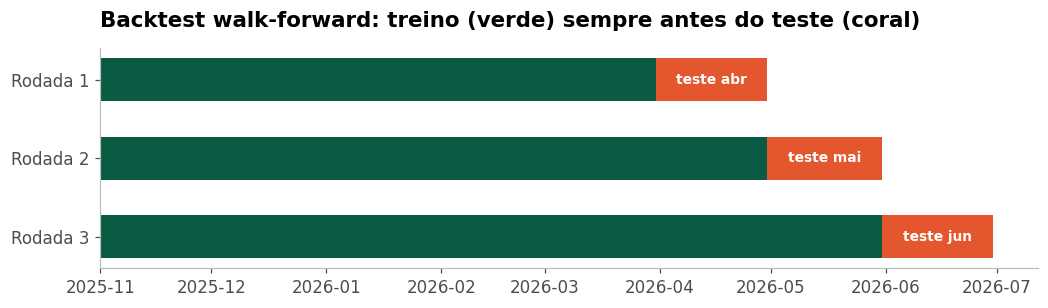

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.6))
ini = y.index.min()
for i, c in enumerate(CORTES):
    c = pd.Timestamp(c); fim = c + pd.offsets.MonthEnd(1)
    ax.barh(i, (c - ini).days, left=ini, color=VERDE, height=0.55)
    ax.barh(i, (fim - c).days, left=c, color=CORAL, height=0.55)
    ax.text(c + (fim-c)/2, i, "teste " + MESES[fim.month], ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax.set_yticks(range(3)); ax.set_yticklabels(["Rodada 1", "Rodada 2", "Rodada 3"]); ax.invert_yaxis()
ax.grid(False); ax.set_title("Backtest walk-forward: treino (verde) sempre antes do teste (coral)")
salvar(fig, "03_esquema_backtest"); plt.show()

## 4. Baselines e modelos candidatos

Sem baseline, nenhum número de erro significa nada. A pergunta que o modelo precisa responder é: **ele erra menos do que as regras simples que o time já usaria?**

| Modelo | Por que testar |
|---|---|
| Naive sazonal: repetir o mesmo dia da semana passada | A regra mais simples possível |
| Média do mesmo dia da semana nas últimas 4 semanas | Regra de planejamento comum no varejo; suaviza ruído |
| Ridge (regressão linear regularizada) | Interpretável, robusta com pouco dado |
| LightGBM (gradient boosting de árvores) | Captura não linearidades e interações (ex.: sexta + semana pré-evento) que a regressão linear não pega; funciona bem com poucas linhas se as árvores forem rasas |

**Por que não redes neurais (LSTM etc.):** com ~240 pontos diários, uma rede neural decora o treino. O volume de dados não justifica. **Por que não Prophet/ARIMA como principal:** eles modelam bem sazonalidade, mas incorporam pior as features de eventos com rampa e interação com dia da semana; ficam como próximo passo de comparação.

In [4]:
def naive_sazonal(Xtr, ytr, Xte): return np.expm1(Xte.lag_7.values)
def media_4_semanas(Xtr, ytr, Xte): return np.expm1(Xte.mesmo_dia_media_4sem.values)
def ridge(Xtr, ytr, Xte):
    Xd = pd.get_dummies(pd.concat([Xtr, Xte]), columns=["dia_semana"], dtype=float)
    m = make_pipeline(StandardScaler(), Ridge(alpha=3)).fit(Xd.iloc[:len(Xtr)], np.log1p(ytr))
    return np.expm1(m.predict(Xd.iloc[len(Xtr):]))
PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=4, min_child_samples=5, subsample=0.8,
              subsample_freq=1, colsample_bytree=0.8, reg_lambda=1, random_state=42, verbose=-1)
def lightgbm(Xtr, ytr, Xte):
    return np.expm1(lgb.LGBMRegressor(**PARAMS).fit(Xtr, np.log1p(ytr)).predict(Xte))

modelos = {"Naive sazonal": naive_sazonal, "Média 4 semanas": media_4_semanas, "Ridge": ridge, "LightGBM": lightgbm}
res, preds = {}, {}
for nome, f in modelos.items():
    r, p = backtest(y, X, f); res[nome] = r.set_index("teste"); preds[nome] = p
tabela = pd.concat({n: r[["WAPE", "viés"]] for n, r in res.items()}, axis=1)
resumo = pd.DataFrame({n: {"WAPE médio": r.WAPE.mean(), "MAPE médio": r.MAPE.mean(), "viés médio": r["viés"].mean()} for n, r in res.items()}).T
display(tabela); resumo.sort_values("WAPE médio")

Naive sazonal        Média 4 semanas        Ridge        LightGBM  \
                  WAPE   viés            WAPE   viés  WAPE   viés     WAPE   
teste                                                                        
abr/2026         0.137 -0.090           0.142 -0.016 0.284  0.146    0.107   
mai/2026         0.524  0.022           0.406 -0.174 0.385 -0.267    0.367   
jun/2026         0.348 -0.018           0.336  0.141 0.271  0.051    0.264   

                 
           viés  
teste            
abr/2026 -0.060  
mai/2026 -0.335  
jun/2026  0.066

,WAPE médio,MAPE médio,viés médio
LightGBM,0.246,0.235,-0.110
Média 4 semanas,0.295,0.311,-0.016
Ridge,0.313,0.310,-0.024
Naive sazonal,0.336,0.357,-0.029


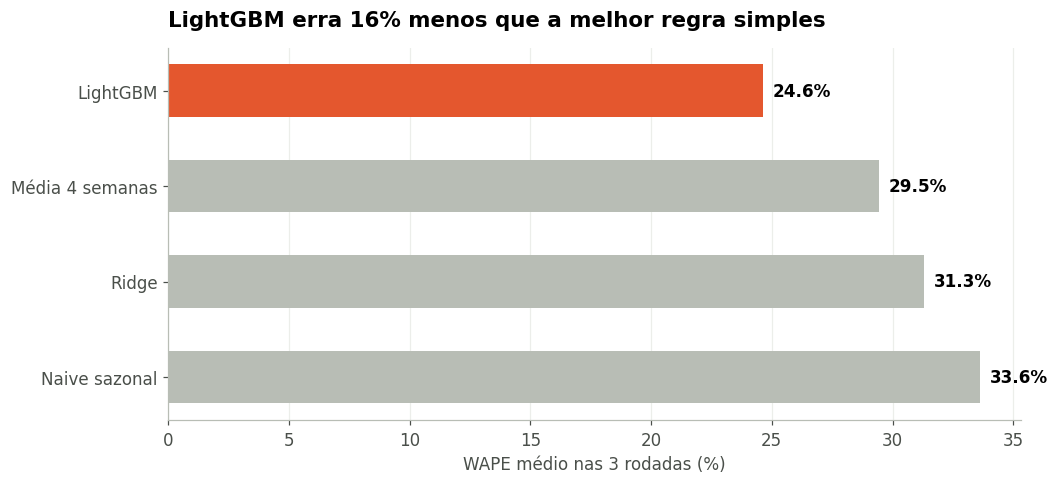

Ganho do LightGBM sobre o melhor baseline: 16.4%


In [5]:
fig, ax = plt.subplots(figsize=(10, 4.4))
ordem = resumo.sort_values("WAPE médio", ascending=False)
cores = [CORAL if n == "LightGBM" else CINZA for n in ordem.index]
ax.barh(ordem.index, ordem["WAPE médio"]*100, color=cores, height=0.55)
for i, v in enumerate(ordem["WAPE médio"]*100): ax.text(v+0.4, i, f"{v:.1f}%", va="center", fontweight="bold")
ganho = 1 - resumo.loc["LightGBM", "WAPE médio"] / resumo.loc[["Naive sazonal", "Média 4 semanas"], "WAPE médio"].min()
ax.set_xlabel("WAPE médio nas 3 rodadas (%)"); ax.grid(axis="y", visible=False)
ax.set_title(f"LightGBM erra {ganho:.0%} menos que a melhor regra simples")
salvar(fig, "03_comparacao_modelos"); plt.show()
print(f"Ganho do LightGBM sobre o melhor baseline: {ganho:.1%}")

**Leitura:** o LightGBM vence na média e em todas as rodadas contra os baselines. A Ridge perde para a média de 4 semanas: a relação entre calendário, eventos e nível recente não é linear, e o modelo linear extrapola mal o nível depois de novembro. Pequenas variações de hiperparâmetros (folhas de 4 a 16, 300 a 600 árvores) deram WAPE entre 24,6% e 25,4%: o resultado é estável, não fruto de ajuste fino. Daqui em diante, **todas as análises são do modelo vencedor, o LightGBM.**

## 5. O modelo vencedor de perto

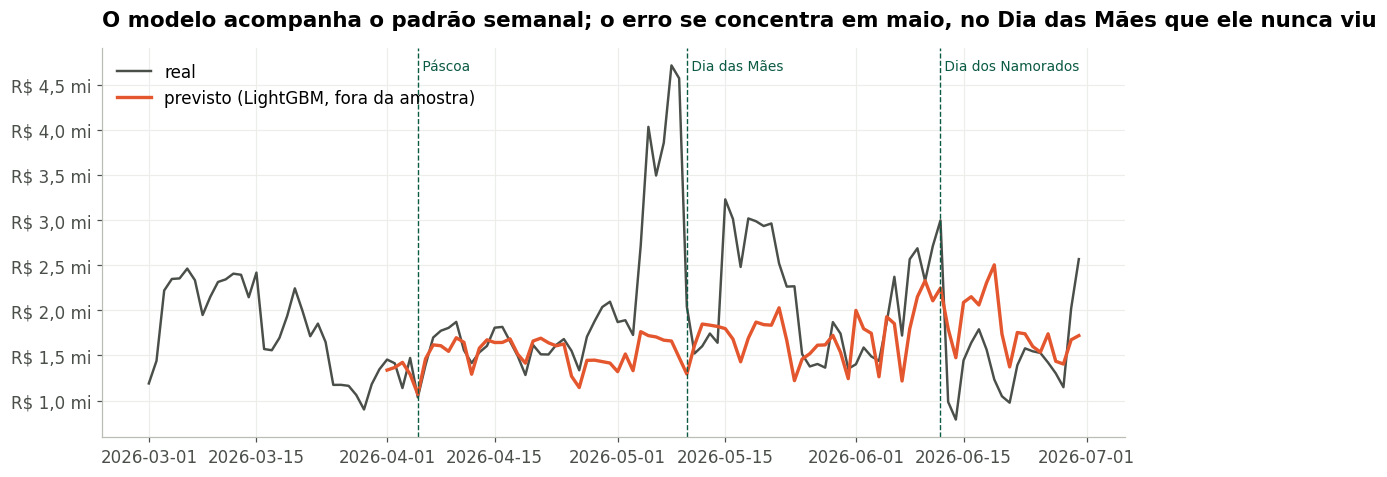

In [6]:
p = preds["LightGBM"]; real = y.loc[p.index]
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(y.loc["2026-03-01":].index, y.loc["2026-03-01":], color=CINZA_ESC, lw=1.6, label="real")
ax.plot(p.index, p, color=CORAL, lw=2.2, label="previsto (LightGBM, fora da amostra)")
for nome in ["Páscoa", "Dia das Mães", "Dia dos Namorados"]:
    ax.axvline(pd.Timestamp(EVENTOS[nome]), color=VERDE, ls="--", lw=0.9); ax.text(pd.Timestamp(EVENTOS[nome]), ax.get_ylim()[1]*0.95, f" {nome}", color=VERDE, fontsize=9)
ax.yaxis.set_major_formatter(mt.FuncFormatter(reais_mi)); ax.legend(loc="upper left")
ax.set_title("O modelo acompanha o padrão semanal; o erro se concentra em maio, no Dia das Mães que ele nunca viu")
salvar(fig, "03_real_vs_previsto"); plt.show()

In [7]:
err = pd.DataFrame({"real": real, "previsto": p, "erro_abs": (p - real).abs()})
semana_maes = (err.index >= "2026-05-04") & (err.index <= "2026-05-10")
maio = err.index.month == 5
print(f"WAPE do backtest inteiro (91 dias): {wape(err.real, err.previsto):.1%}")
print(f"WAPE de maio: {wape(err.real[maio], err.previsto[maio]):.1%}")
print(f"WAPE de maio sem a semana do Dia das Mães: {wape(err.real[~semana_maes & (err.index.month==5)], err.previsto[~semana_maes & (err.index.month==5)]):.1%}")
print(f"A semana do Dia das Mães (7 de 91 dias) responde por {err.erro_abs[semana_maes].sum()/err.erro_abs.sum():.0%} de todo o erro do backtest")
print(f"WAPE de abr+jun (meses sem data de presente forte no meio): {wape(err.real[err.index.month!=5], err.previsto[err.index.month!=5]):.1%}")

WAPE do backtest inteiro (91 dias): 26.6%
WAPE de maio: 36.7%
WAPE de maio sem a semana do Dia das Mães: 27.2%
A semana do Dia das Mães (7 de 91 dias) responde por 30% de todo o erro do backtest
WAPE de abr+jun (meses sem data de presente forte no meio): 18.9%


### Por que o modelo erra o Dia das Mães, e o que fazer

Com 8 meses de base, **cada data comemorativa aparece uma vez.** A rodada que testa maio nunca viu um Dia das Mães no treino; o único evento de presente parecido no treino é o Natal, que nesta base teve rampa fraca. Nenhum algoritmo aprende o efeito de algo que nunca viu. O que fizemos e o que recomendamos:

1. Features genéricas de evento (dias até a próxima data de presente, semana pré-presente) em vez de uma flag por evento. Assim o modelo aprende "padrão de data de presente", e a rodada de junho já se beneficia de ter visto maio.
2. Em produção: **o modelo entrega a linha de base e o time comercial aplica o ajuste de evento** a partir do plano de campanha. É como grandes varejistas operam forecast de datas sazonais.
3. Com 2 anos ou mais de histórico, o efeito de cada evento passa a ser aprendido diretamente (lag de 52 semanas).

## 6. O que move a venda (SHAP do LightGBM)

O SHAP mede quanto cada feature empurrou a previsão de cada dia para cima ou para baixo. Calculado no LightGBM treinado até 31/05 (última rodada), sobre os dias de junho.

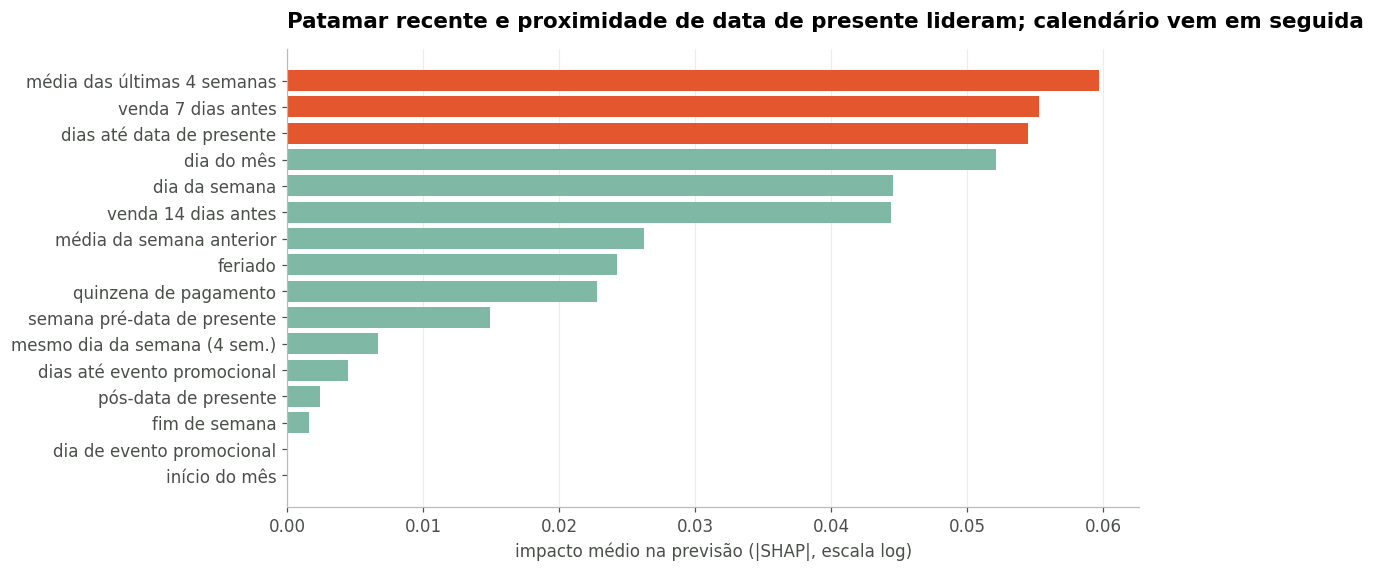

In [8]:
tr = (y.index <= "2026-05-31") & X.notna().all(axis=1); te = (y.index > "2026-05-31")
modelo = lgb.LGBMRegressor(**PARAMS).fit(X[tr], np.log1p(y[tr]))
expl = shap.TreeExplainer(modelo); sv = expl.shap_values(X[te])
NOMES = {"media_28_lag7": "média das últimas 4 semanas", "lag_7": "venda 7 dias antes", "lag_14": "venda 14 dias antes",
         "media_7_lag7": "média da semana anterior", "mesmo_dia_media_4sem": "mesmo dia da semana (4 sem.)",
         "dias_ate_evento_presente": "dias até data de presente", "dias_ate_evento_promo": "dias até evento promocional",
         "semana_pre_presente": "semana pré-data de presente", "pos_evento_presente": "pós-data de presente",
         "dia_evento_promo": "dia de evento promocional", "dia_semana": "dia da semana", "dia_mes": "dia do mês",
         "fim_de_semana": "fim de semana", "inicio_mes": "início do mês", "quinzena_pagamento": "quinzena de pagamento",
         "feriado": "feriado"}
imp = pd.Series(np.abs(sv).mean(0), index=[NOMES[c] for c in X.columns]).sort_values()
fig, ax = plt.subplots(figsize=(10, 5.4))
cores = [CORAL if i >= len(imp)-3 else VERDE_CLARO for i in range(len(imp))]
ax.barh(imp.index, imp.values, color=cores)
ax.set_xlabel("impacto médio na previsão (|SHAP|, escala log)"); ax.grid(axis="y", visible=False)
ax.set_title("Patamar recente e proximidade de data de presente lideram; calendário vem em seguida")
salvar(fig, "03_importancia_shap"); plt.show()

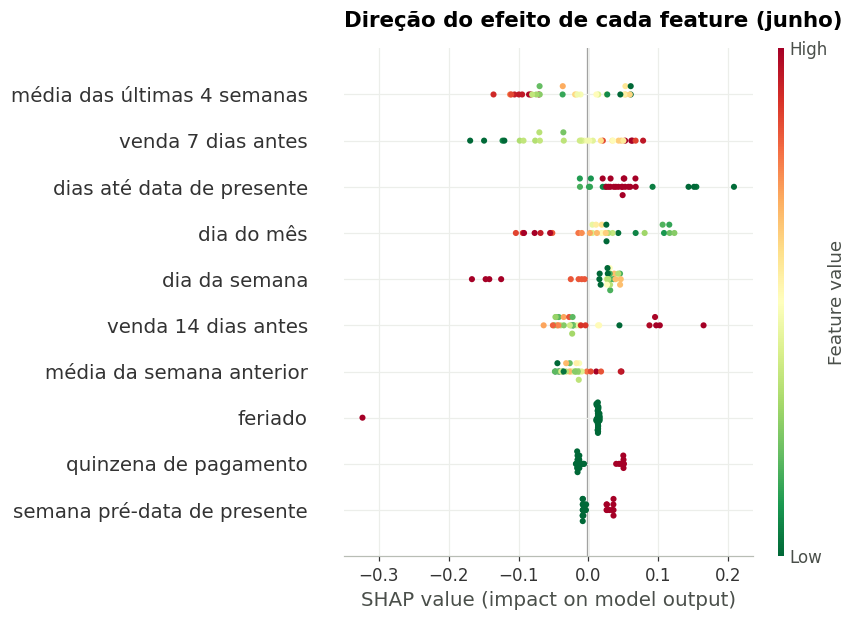

In [9]:
plt.figure(); shap.summary_plot(sv, X[te].rename(columns=NOMES), show=False, max_display=10, cmap=plt.get_cmap("RdYlGn_r"))
plt.title("Direção do efeito de cada feature (junho)", loc="left", fontweight="bold")
plt.savefig("../reports/figures/03_shap_beeswarm.png", bbox_inches="tight", dpi=200); plt.show()

**Tradução para o negócio:** a venda de um dia é explicada, nesta ordem, pelo **patamar das últimas semanas** (média de 4 semanas e venda de 7 dias antes), pela **distância até a próxima data de presente** e pelo **calendário** (dia do mês e dia da semana). O modelo confirma o que a EDA mostrou: a rampa antes das datas de presente pesa mais que o dia do evento em si, e o dia da semana tem efeito estável.

## 7. Faixa de previsão, não só número

Planejamento de estoque e escala trabalha com faixa. Primeira tentativa (testada e descartada): o mesmo LightGBM com perda quantílica (10% e 90%). A faixa ficou estreita demais e cobriu só metade dos dias: com ~200 dias de treino, o modelo fica confiante demais. Abordagem adotada, mais robusta com pouco dado: **faixa empírica a partir dos erros do próprio LightGBM no backtest** (conformal simples). Para cada mês de teste, a faixa usa os erros dos **outros** meses, para não olhar a resposta.

Cobertura da faixa 10%-90%: 65% dos dias | fora da semana do Dia das Mães: 70%


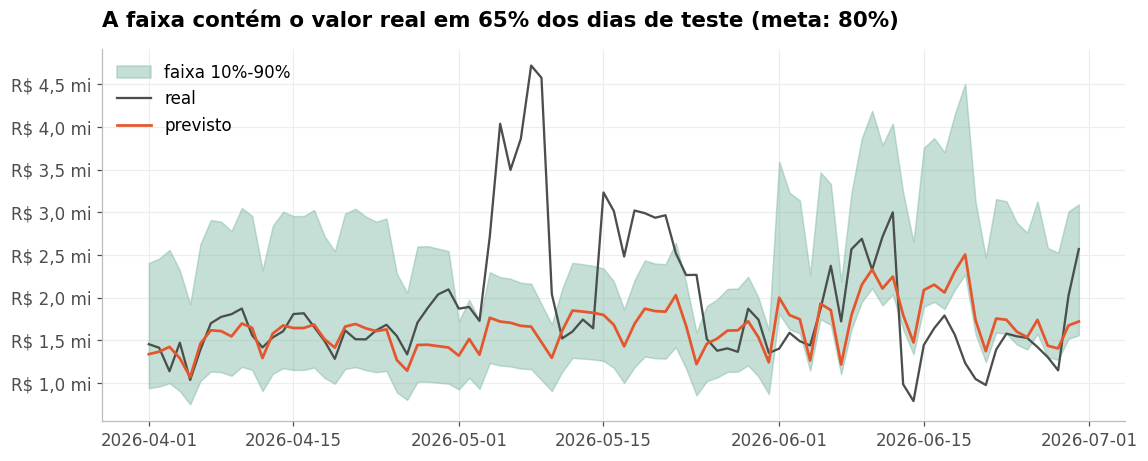

In [10]:
res_log = np.log(real) - np.log(p)
mes = p.index.month
lo, hi = pd.Series(index=p.index, dtype=float), pd.Series(index=p.index, dtype=float)
for m_ in np.unique(mes):
    outros = res_log[mes != m_]
    lo[mes == m_] = p[mes == m_] * np.exp(outros.quantile(0.1))
    hi[mes == m_] = p[mes == m_] * np.exp(outros.quantile(0.9))
dentro = (real >= lo) & (real <= hi)
fora_maes = ~((real.index >= "2026-05-04") & (real.index <= "2026-05-10"))
print(f"Cobertura da faixa 10%-90%: {dentro.mean():.0%} dos dias | fora da semana do Dia das Mães: {dentro[fora_maes].mean():.0%}")
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.fill_between(p.index, lo, hi, color=VERDE_CLARO, alpha=0.45, label="faixa 10%-90%")
ax.plot(real.index, real, color=CINZA_ESC, lw=1.5, label="real"); ax.plot(p.index, p, color=CORAL, lw=1.8, label="previsto")
ax.yaxis.set_major_formatter(mt.FuncFormatter(reais_mi)); ax.legend(loc="upper left")
ax.set_title(f"A faixa contém o valor real em {dentro.mean():.0%} dos dias de teste (meta: 80%)")
salvar(fig, "03_faixa_previsao"); plt.show()
Q_LO, Q_HI = res_log.quantile(0.1), res_log.quantile(0.9)

A faixa empírica cobre 65% dos dias, contra 51% da quantílica, mas ainda abaixo da meta de 80%. A faixa é assimétrica para cima: o modelo erra mais subestimando picos do que superestimando. Os dias que escapam se concentram na rampa e na ressaca das datas comemorativas, efeito que o modelo não tem como aprender com um ano incompleto. Para essas datas, o ajuste comercial continua obrigatório; com mais histórico, a faixa fica mais bem calibrada.

## 8. Previsão para a primeira semana de julho

Modelo final: o mesmo LightGBM, treinado com todos os dados até 30/06. Como os lags começam em 7, a semana de 01 a 07/07 pode ser prevista só com dados já conhecidos.

In [11]:
fut_idx = pd.date_range("2026-07-01", "2026-07-07")
y_ext = pd.concat([y, pd.Series(np.nan, index=fut_idx)])
X_ext = montar_features(y_ext)
treino = X_ext.index <= "2026-06-30"
ok = treino & X_ext.notna().all(axis=1)
final = lgb.LGBMRegressor(**PARAMS).fit(X_ext[ok], np.log1p(y_ext[ok]))
pt = np.expm1(final.predict(X_ext.loc[fut_idx]))
lo, hi = pt * np.exp(Q_LO), pt * np.exp(Q_HI)  # faixa empírica da seção 7
prev = pd.DataFrame({"dia": [["Seg","Ter","Qua","Qui","Sex","Sáb","Dom"][d.dayofweek] for d in fut_idx],
                     "previsto (R$ mi)": pt/1e6, "p10 (R$ mi)": lo/1e6, "p90 (R$ mi)": hi/1e6}, index=fut_idx.strftime("%d/%m"))
print(f"Semana prevista: R$ {pt.sum()/1e6:.1f} mi (faixa R$ {lo.sum()/1e6:.1f} a {hi.sum()/1e6:.1f} mi)")
prev.round(2)

Semana prevista: R$ 14.1 mi (faixa R$ 11.2 a 24.5 mi)


,dia,previsto (R$ mi),p10 (R$ mi),p90 (R$ mi)
01/07,Qua,2.120,1.680,3.670
02/07,Qui,2.130,1.690,3.690
03/07,Sex,2.020,1.600,3.510
04/07,Sáb,1.760,1.390,3.050
05/07,Dom,1.360,1.080,2.360
06/07,Seg,2.280,1.810,3.970
07/07,Ter,2.460,1.950,4.270


## 9. Limitações e próximos passos

**Limitações**
- 242 dias: cada evento sazonal aparece uma vez; o modelo não aprende o efeito específico de cada data.
- Novembro é um regime à parte (Black November). O modelo usa os lags para se adaptar, mas não temos outro novembro para validar a previsão de campanha.
- Desconto não entra como feature: só seria válido se fosse o desconto **planejado** (conhecido antes), dado que não está na base.
- O backtest tem 3 rodadas; com mais histórico, o ideal são rodadas semanais.

**Próximos passos**
1. Incluir o calendário comercial (campanhas e desconto planejados) como feature: é o maior ganho esperado.
2. Forecast por canal e categoria com reconciliação hierárquica (soma das partes = total).
3. Lag de 52 semanas assim que houver um ano completo.
4. Previsão intradiária: com 31% da receita conhecida ao meio-dia, um modelo de fechamento do dia corrige o forecast no próprio dia.
5. Produção: job diário, retreino semanal, monitoramento de WAPE com alerta.